In [1]:
from astropy import units as u
from copy import copy
import jax.numpy as jnp
from astropy.coordinates import SkyCoord, Galactocentric

import matplotlib.pyplot as plt
import jax
jax.config.update("jax_enable_x64", True)

from streamsculptor import potential
from streamsculptor import JaxCoords as jc
import diffrax
import matplotlib as mpl
import scienceplots
plt.style.use('science')
mpl.rcParams['text.usetex'] = False

# eqx_everything branch: usys lives in streamsculptor.main
from streamsculptor.main import usys

# New bfeax-based TNFW implementation
from streamsculptor.tnfw import (
    TNFWPotential,
    TNFWSubhaloLinePotential,
    _nfw_params_from_infall,
    _tidally_evolved_nfw_params,
)

# Convenience aliases matching main-branch names used below
HernquistPotential                  = potential.HernquistPotential
make_tnfw_potential_from_profile    = TNFWPotential.from_profile
make_tnfw_potential_from_infall     = TNFWPotential.from_infall
tidally_evolved_nfw_params_from_infall = _tidally_evolved_nfw_params
nfw_params_from_infall              = _nfw_params_from_infall


def tnfw_enclosed_mass(R, rhos, rs, ft, rt):
    """Analytic enclosed mass of the truncated NFW profile (Baltz+2009)."""
    tau = rt / rs
    u   = R  / rs
    t2  = tau ** 2
    term1 = (t2 - 1) / (t2 + 1) ** 2 * jnp.log(1 + u)
    term2 = 1 / (t2 + 1) * (1 / (1 + u) - 1)
    term3 = -(t2 - 1) / (2 * (t2 + 1) ** 2) * jnp.log(1 + u ** 2 / t2)
    term4 = 2 * tau / (t2 + 1) ** 2 * jnp.arctan(u / tau)
    return 4 * jnp.pi * rhos * ft * rs ** 3 * t2 * (term1 + term2 + term3 + term4)

First we will define a gd-1 centric frame. These transformations are written in Jax so they can be differentiated.

In [2]:
@jax.jit
def icrs_to_gd1(ra_rad, dec_rad):
    """
    define a *differentiable* coordinate transfrom from ra and dec --> gd1 phi1, phi2
    Using the rotation matrix from Koposov+2010
    ra_rad: icrs ra [radians]
    dec_red: icrs dec [radians]
    """
    R = jnp.array(
        [
            [-0.4776303088, -0.1738432154, 0.8611897727],
            [0.510844589, -0.8524449229, 0.111245042],
            [0.7147776536, 0.4930681392, 0.4959603976],
        ]
    )

    icrs_vec = jnp.vstack([jnp.cos(ra_rad)*jnp.cos(dec_rad),
                           jnp.sin(ra_rad)*jnp.cos(dec_rad),
                           jnp.sin(dec_rad)]).T

    stream_frame_vec = jnp.einsum('ij,kj->ki', R, icrs_vec)

    phi1 = jnp.arctan2(stream_frame_vec[:,1], stream_frame_vec[:,0]) * 180 / jnp.pi
    phi2 = jnp.arcsin(stream_frame_vec[:,2]) * 180 / jnp.pi

    return phi1, phi2

@jax.jit
def get_phi12_from_stream(stream):
    """
    Differentiable helper function that takes us from simulated stream --> phi1, phi2
    """
    ra_s, dec_s, dist_ = jax.vmap(jc.simcart_to_icrs)(stream[:,:3])
    phi1_model, phi2_model = icrs_to_gd1(ra_s*jnp.pi/180, dec_s*jnp.pi/180)
    return phi1_model, phi2_model

Estimated progenitor location today in [kpc, kpc, kpc, kpc/Myr, kpc/Myr, kpc/Myr]
Estimated in a separate file, but will provide a good starting point for this notebook. This file can be found in the data folder of the streamsculptor repository:
``data/GD1_prog/GD1_progenitor.npy``

In [3]:
prog_wtoday = jnp.load('../data/GD1_prog/GD1_progenitor.npy', allow_pickle=True).item()
pos = prog_wtoday.pos.xyz.to(u.kpc).value
vel = prog_wtoday.vel.d_xyz.to(u.kpc/u.Myr).value
prog_wtoday = jnp.hstack([pos, vel])

In [4]:
## Use Gala's MW potential
pot = potential.GalaMilkyWayPotential(units=usys)
## Define the age of the stream [Myr]
t_age = 2500.0
## Past time at which it dissolved [Myr]
t_dissolve = -300.0
## Get initial conditions
IC = pot.integrate_orbit(w0=prog_wtoday, t0=0.0, t1=-t_age, ts=jnp.array([-t_age])).ys[0]
## Define stripping times. ts[-1] is always the final integration time for gen_stream simulations
ts = jnp.hstack([jnp.linspace(-t_age, t_dissolve, 2_000), jnp.array([0.0])])
## Generate unperturbed stream [l: lead, t: trail]
l, t = pot.gen_stream_scan(prog_w0=IC, ts=ts, seed_num=532, Msat=1e4, atol=1e-6, rtol=1e-6, solver=diffrax.Dopri5())
stream = jnp.vstack([l, t])

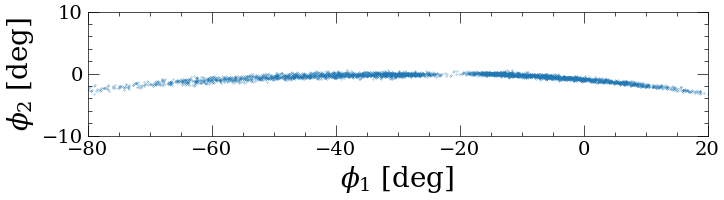

In [5]:
phi1_model, phi2_model = get_phi12_from_stream(stream)

fig, ax = plt.subplots(1, 1)
fig.set_size_inches(8, 8)
ax.scatter(phi1_model, phi2_model, s=.05, color='tab:blue')

ax.tick_params(axis='both', which='major', labelsize=14., length=8)
ax.tick_params(axis='both', which='minor', length=3)
ax.set_ylim(-10, 10)
ax.set_xlim(-80, 20)
ax.set_xlabel(r'$\phi_1$ [deg]', fontsize=20)
ax.set_ylabel(r'$\phi_2$ [deg]', fontsize=20)
ax.set_aspect('equal')

In [6]:
from streamsculptor.GenerateImpactParams import ImpactGenerator

number_of_halos = 100
ImpactGen = ImpactGenerator(pot=pot,
                            tobs=0.0,
                            stream=stream,
                            stream_phi1=phi1_model,
                            phi1_bounds=[-80., 20.],
                            tImpactBounds=[-2500, 0.0],
                            phi1window=.8,
                            NumImpacts=number_of_halos,
                            bImpact_bounds=[0, .1],
                            stripping_times=jnp.hstack([ts[:-1], ts[:-1]]),
                            prog_today=prog_wtoday,
                            seednum=10)

ImpactDict = ImpactGen.get_subhalo_ImpactParams()
print(ImpactDict.keys())

dict_keys(['CartesianImpactParams', 'ImpactFrameParams'])


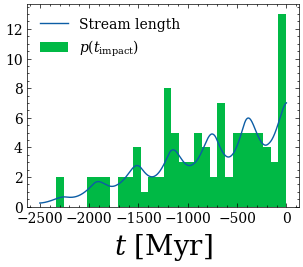

In [7]:
tImp = ImpactDict['ImpactFrameParams']['tImpact']
length_osc = ImpactGen.length_osc
plt.plot(length_osc['ts'], length_osc['length_func']/3, label='Stream length')
plt.hist(tImp, bins=30, label=r'$p(t_{\rm impact})$');
plt.xlabel(r'$t$ [Myr]', fontsize=20)
plt.legend()

In [8]:
ImpactDict['CartesianImpactParams'].sum()

Array(336.16763239, dtype=float64)

In [9]:
ImpactDict['ImpactFrameParams'].keys()

dict_keys(['bImpact', 'perp_angle', 'phi1_samples', 'tImpact'])

In [10]:
# Impact parameters (b)
ImpactDict['ImpactFrameParams']['bImpact']

Array([7.21358115e-02, 7.73629301e-02, 5.58061760e-02, 2.26208087e-03,
       9.20794380e-03, 5.31836753e-02, 8.36127572e-02, 3.12282665e-02,
       5.46345345e-02, 6.07300468e-02, 4.00623125e-02, 5.68539231e-02,
       8.01200494e-03, 7.73439933e-02, 1.49121081e-02, 4.46874414e-02,
       1.55029196e-02, 5.37932671e-02, 8.40633967e-02, 2.25392825e-02,
       2.91539068e-02, 5.93213503e-02, 9.22899942e-03, 9.46581594e-02,
       9.97305545e-02, 9.71944379e-02, 5.49563096e-02, 6.95825214e-02,
       3.42810959e-03, 8.85539785e-02, 6.37655038e-05, 5.96918901e-02,
       3.38947537e-02, 7.34903957e-02, 1.62219101e-02, 8.44646165e-03,
       9.64070984e-02, 2.20592629e-02, 6.42621402e-02, 8.44463202e-02,
       4.38948444e-03, 6.74464130e-02, 7.06745367e-02, 8.29015090e-02,
       9.89396357e-02, 8.20395539e-02, 9.89184785e-02, 9.18239046e-02,
       6.22025487e-02, 4.59887177e-02, 6.61103407e-02, 7.00953100e-02,
       2.74303698e-02, 1.65415686e-02, 2.39025274e-02, 6.91992268e-02,
      

Compare Hernquist vs TNFW profiles with `a = r_s`

In [11]:
from streamsculptor import gen_stream_vmapped_with_pert

In [12]:
@jax.jit
def gen_perturbed_stream_TNFW(m_infall, c_infall, z_infall, f_bound, ImpactDict):
    # eqx_everything: use TNFWSubhaloLinePotential.from_infall instead of positional constructor
    pot_SH = TNFWSubhaloLinePotential.from_infall(
        m_infall=m_infall,
        c_infall=c_infall,
        z_infall=z_infall,
        f_bound=f_bound,
        subhalo_x0=ImpactDict['CartesianImpactParams'][0:index_max, :3],
        subhalo_v=ImpactDict['CartesianImpactParams'][0:index_max, 3:],
        subhalo_t0=ImpactDict['ImpactFrameParams']['tImpact'][0:index_max],
        t_window=150.0,
        n_r=64
    )
    pot_lst = [pot, pot_SH]
    pot_total = potential.Potential_Combine(pot_lst, units=usys)

    IC = pot_total.integrate_orbit(w0=prog_wtoday, t0=0.0, t1=-t_age, ts=jnp.array([-t_age]), max_steps=10_000).ys[0]
    l, t = gen_stream_vmapped_with_pert(pot_base=pot, pot_pert=pot_SH, prog_w0=IC, ts=ts, seed_num=532, Msat=1e4,
                                        max_steps=5_000, atol=1e-6, rtol=1e-6, solver=diffrax.Dopri5(), dtmin=.05)
    stream = jnp.vstack([l, t])
    return stream


def gen_perturbed_stream(m, rs, ImpactDict):
    pot_SH = potential.SubhaloLinePotential(
        m=m,
        a=rs,
        subhalo_x0=ImpactDict['CartesianImpactParams'][0:index_max, :3],
        subhalo_v=ImpactDict['CartesianImpactParams'][0:index_max, 3:],
        subhalo_t0=ImpactDict['ImpactFrameParams']['tImpact'][0:index_max],
        t_window=jnp.array([150.0]),
        units=usys,
    )
    pot_lst = [pot, pot_SH]
    pot_total = potential.Potential_Combine(pot_lst, units=usys)

    IC = pot_total.integrate_orbit(w0=prog_wtoday, t0=0.0, t1=-t_age, ts=jnp.array([-t_age]), max_steps=10_000).ys[0]
    l, t = gen_stream_vmapped_with_pert(pot_base=pot, pot_pert=pot_SH, prog_w0=IC, ts=ts, seed_num=532, Msat=1e4,
                                        max_steps=5_000, atol=1e-6, rtol=1e-6, solver=diffrax.Dopri5(), dtmin=.05)
    stream = jnp.vstack([l, t])
    return stream


def sample_mass_function(n, slope=1.9, m_low=6.0, m_high=10):
    import numpy as np
    x = np.random.uniform(0, 1, n)
    m = (x * (m_high**(1 - slope) - m_low**(1 - slope)) + m_low**(1 - slope))**((1 - slope)**-1)
    return 10**m

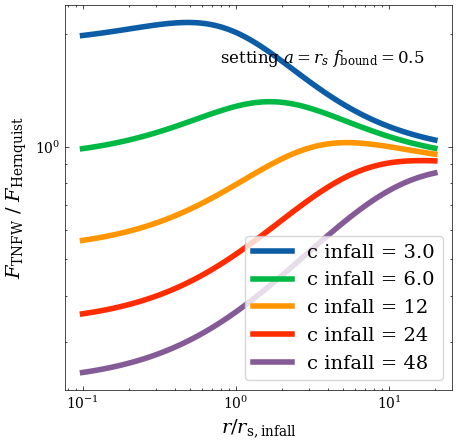

Text(0, 0.5, '$F_{\\rm{TNFW}} \\ / \\ F_{\\rm{Hernquist}}$')

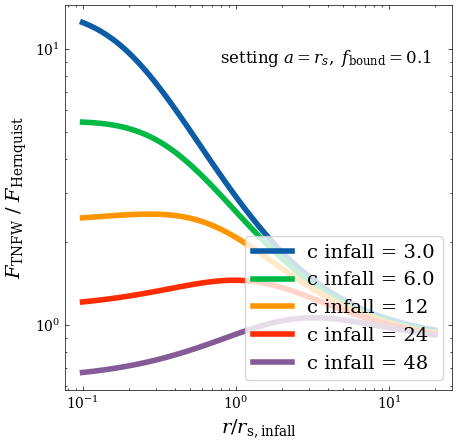

In [13]:
m_infall = 10**8
z_infall = 1.0
f_bound = 0.5

fig = plt.figure(1)
fig.set_size_inches(5, 5)
ax = plt.subplot(111)
for c_infall in [3.0, 6.0, 12, 24, 48]:
    rhos, rs, ft, rt = tidally_evolved_nfw_params_from_infall(m_infall, c_infall, z_infall, f_bound)
    # eqx_everything: TNFWPotential.from_profile instead of make_tnfw_potential_from_density_profile
    pot_tnfw = make_tnfw_potential_from_profile(rhos, rs, ft, rt)

    m_hernquist = tnfw_enclosed_mass(c_infall * rs, rhos, rs, ft, rt) / 0.84
    scale_rs_hernquist = 1.
    rs_hernquist = copy(rs) * scale_rs_hernquist
    pot_hernquist = HernquistPotential(m=m_hernquist, r_s=rs_hernquist, units=usys)

    r = jnp.logspace(-1, 1.3, 100) * rs

    forces_tnfw      = jnp.array([jnp.linalg.norm(pot_tnfw.gradient(jnp.array([ri, 0.0, 0.0]), 0.0)) for ri in r])
    forces_hernquist = jnp.array([jnp.linalg.norm(pot_hernquist.gradient(jnp.array([ri, 0.0, 0.0]), 0.0)) for ri in r])

    plt.loglog(r/rs, forces_tnfw/forces_hernquist, label='c infall = '+str(c_infall), lw=4)

ax.legend(fontsize=14, loc=4, frameon=True)
ax.annotate('setting '+r'$a = r_s \ $'+r'$f_{\rm{bound}}=0.5$', xy=(0.4, 0.85), fontsize=12, xycoords='axes fraction')
ax.set_xlabel(r'$r / r_{\rm{s,infall}}$', fontsize=14)
ax.set_ylabel(r'$F_{\rm{TNFW}} \ / \ F_{\rm{Hernquist}}$', fontsize=14)
plt.show()

m_infall = 10**8
z_infall = 1.0
f_bound = 0.1

fig = plt.figure(2)
fig.set_size_inches(5, 5)
ax = plt.subplot(111)
for c_infall in [3.0, 6.0, 12, 24, 48]:
    rhos, rs, ft, rt = tidally_evolved_nfw_params_from_infall(m_infall, c_infall, z_infall, f_bound)
    pot_tnfw = make_tnfw_potential_from_profile(rhos, rs, ft, rt)

    m_hernquist = tnfw_enclosed_mass(c_infall * rs, rhos, rs, ft, rt) / 0.84
    scale_rs_hernquist = 1.
    rs_hernquist = copy(rs) * scale_rs_hernquist
    pot_hernquist = HernquistPotential(m=m_hernquist, r_s=rs_hernquist, units=usys)

    r = jnp.logspace(-1, 1.3, 100) * rs

    forces_tnfw      = jnp.array([jnp.linalg.norm(pot_tnfw.gradient(jnp.array([ri, 0.0, 0.0]), 0.0)) for ri in r])
    forces_hernquist = jnp.array([jnp.linalg.norm(pot_hernquist.gradient(jnp.array([ri, 0.0, 0.0]), 0.0)) for ri in r])

    plt.loglog(r/rs, forces_tnfw/forces_hernquist, label='c infall = '+str(c_infall), lw=4)

ax.legend(fontsize=14, loc=4, frameon=True)
ax.annotate('setting '+r'$a = r_s, \ $'+r'$f_{\rm{bound}}=0.1$', xy=(0.4, 0.85), fontsize=12, xycoords='axes fraction')
ax.set_xlabel(r'$r / r_{\rm{s,infall}}$', fontsize=14)
ax.set_ylabel(r'$F_{\rm{TNFW}} \ / \ F_{\rm{Hernquist}}$', fontsize=14)

In [14]:
from pyHalo.Halos.accretion import InfallDistributionDirectMilkyWay30kpc
from pyHalo.Halos.concentration import ConcentrationDiemerJoyce
from pyHalo.Halos.galacticus_truncation.interp_mass_loss import InterpGalacticusMW
from astropy.cosmology import Planck18
from colossus.cosmology import cosmology
from scipy.interpolate import interp1d

cosmology.setCosmology('planck18')

tidal_evolution_model = InterpGalacticusMW(rmax=30)  # calibrated for r < 30 kpc in the MW
z_eval = 0.0
logM_MW = 12.0
chost = 9.0
infall_redshift_sampling = InfallDistributionDirectMilkyWay30kpc(z_eval, logM_MW)
concentration_mass_relation = ConcentrationDiemerJoyce(Planck18)
zvalues_interp = jnp.linspace(0.0, 10, 100)
t = [Planck18.lookback_time(zi).value for zi in zvalues_interp]
time_since_infall_interp = interp1d(zvalues_interp, t)

In [15]:
import tqdm

100%|██████████| 1000/1000 [00:00<00:00, 2327.50it/s]


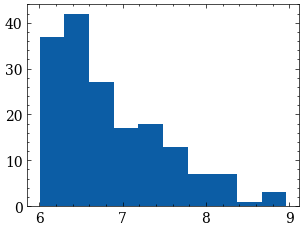

number of infalling perturbers:  1000
number of surviving perturbers:  172


In [16]:
number_of_halos = 1000
_m_infall = sample_mass_function(number_of_halos)

m_infall = []
c_infall = []
z_infall = []
f_bound  = []

bound_mass_cut = 10**6
for m in tqdm.tqdm(_m_infall):
    z = infall_redshift_sampling(m)
    c = concentration_mass_relation.nfw_concentration(m, z)
    t_since_infall = time_since_infall_interp(z)
    log10_fbound = tidal_evolution_model(jnp.log10(c), t_since_infall, chost)

    if m * 10**log10_fbound >= bound_mass_cut:
        m_infall.append(m)
        c_infall.append(c)
        z_infall.append(z)
        f_bound.append(10**log10_fbound)

m_infall = jnp.array(m_infall)
c_infall = jnp.array(c_infall)
z_infall = jnp.array(z_infall)
f_bound  = jnp.array(f_bound)
index_max = len(c_infall)
plt.hist(jnp.log10(f_bound * m_infall)); plt.show()

num_surviving_subhalos = len(m_infall)
print('number of infalling perturbers: ', number_of_halos)
print('number of surviving perturbers: ', num_surviving_subhalos)
ImpactGen = ImpactGenerator(pot=pot,
                            tobs=0.0,
                            stream=stream,
                            stream_phi1=phi1_model,
                            phi1_bounds=[-80., 20.],
                            tImpactBounds=[-2500, 0.0],
                            phi1window=.8,
                            NumImpacts=num_surviving_subhalos,
                            bImpact_bounds=[0, .1],
                            stripping_times=jnp.hstack([ts[:-1], ts[:-1]]),
                            prog_today=prog_wtoday,
                            seednum=10)

In [17]:
index_max

172

In [18]:
ImpactDict = ImpactGen.get_subhalo_ImpactParams()

In [19]:
c_infall.shape, m_infall.shape

((172,), (172,))

In [21]:
perturbed_stream_tnfw = gen_perturbed_stream_TNFW(m_infall, c_infall, z_infall, f_bound, ImpactDict)

In [22]:
perturbed_stream_tnfw.sum()

Array(-21816.13264598, dtype=float64)

In [24]:
m_hernquist = f_bound * m_infall  # the same mass as each TNFW halo
rs_hernquist = 1.05 * jnp.sqrt(m_hernquist / 10**8)

In [25]:
m_hernquist = f_bound * m_infall  # the same mass as each TNFW halo
rs_hernquist = 1.05 * jnp.sqrt(m_hernquist / 10**8)
perturbed_stream_hernquist = gen_perturbed_stream(m_hernquist, rs_hernquist, ImpactDict)

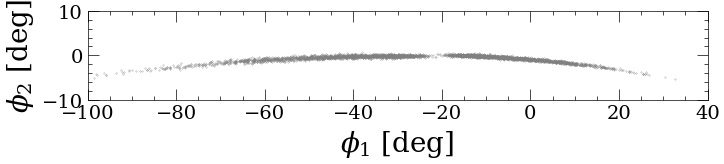

In [26]:
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(8, 8)

ax.scatter(phi1_model, phi2_model, s=.05, color='grey')

ax.tick_params(axis='both', which='major', labelsize=14., length=8)
ax.tick_params(axis='both', which='minor', length=3)
ax.set_ylim(-10, 10)
ax.set_xlim(-100, 40)
ax.set_xlabel(r'$\phi_1$ [deg]', fontsize=20)
ax.set_ylabel(r'$\phi_2$ [deg]', fontsize=20)
ax.set_aspect('equal')

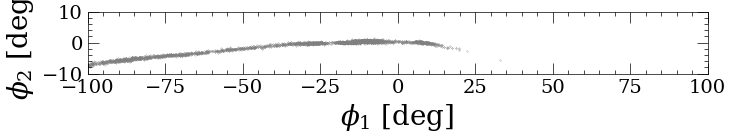

In [27]:
phi1_pert, phi2_pert = get_phi12_from_stream(perturbed_stream_hernquist[:, :3])

fig, ax = plt.subplots(1, 1)
fig.set_size_inches(8, 8)

ax.scatter(phi1_pert, phi2_pert, s=.05, color='grey')

ax.tick_params(axis='both', which='major', labelsize=14., length=8)
ax.tick_params(axis='both', which='minor', length=3)
ax.set_ylim(-10, 10)
ax.set_xlim(-100, 100)
ax.set_xlabel(r'$\phi_1$ [deg]', fontsize=20)
ax.set_ylabel(r'$\phi_2$ [deg]', fontsize=20)
ax.set_aspect('equal')

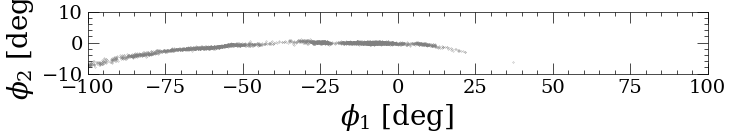

In [28]:
phi1_pert_tnfw, phi2_pert_tnfw = get_phi12_from_stream(perturbed_stream_tnfw[:, :3])

fig, ax = plt.subplots(1, 1)
fig.set_size_inches(8, 8)

ax.scatter(phi1_pert_tnfw, phi2_pert_tnfw, s=.05, color='grey')

ax.tick_params(axis='both', which='major', labelsize=14., length=8)
ax.tick_params(axis='both', which='minor', length=3)
ax.set_ylim(-10, 10)
ax.set_xlim(-100, 100)
ax.set_xlabel(r'$\phi_1$ [deg]', fontsize=20)
ax.set_ylabel(r'$\phi_2$ [deg]', fontsize=20)
ax.set_aspect('equal')

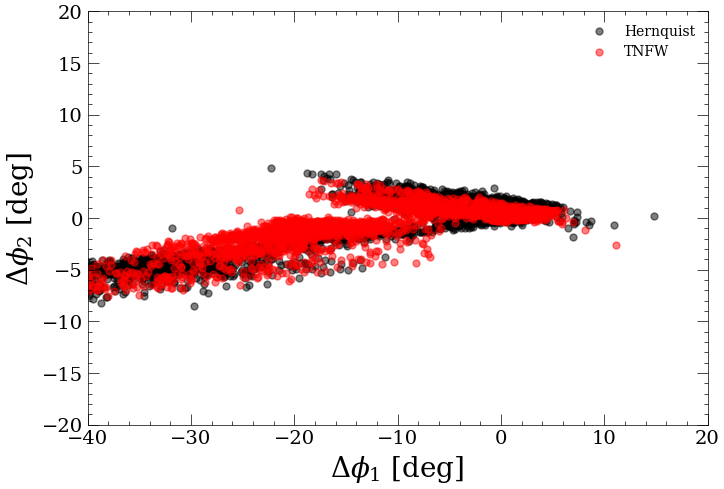

In [30]:
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(8, 8)

ax.scatter(phi1_pert - phi1_model, phi2_pert - phi2_model, s=25, color='k', alpha=0.5, label='Hernquist')
ax.scatter(phi1_pert_tnfw - phi1_model, phi2_pert_tnfw - phi2_model, s=25, color='r', alpha=0.5, label='TNFW')

ax.legend()
ax.tick_params(axis='both', which='major', labelsize=14., length=8)
ax.tick_params(axis='both', which='minor', length=3)
ax.set_ylim(-20, 20)
ax.set_xlim(-40, 20)
ax.set_xlabel(r'$\Delta \phi_1$ [deg]', fontsize=20)
ax.set_ylabel(r'$\Delta \phi_2$ [deg]', fontsize=20)
ax.set_aspect('equal')

In [31]:
bImpact = ImpactDict['ImpactFrameParams']['bImpact']

In [32]:
num_surviving_subhalos

172

In [33]:
from functools import partial

@partial(jax.jit, static_argnames=['n_points'])
def volume_avg_force_hernquist(b, m, rs, n_points=50):
    pot_h = HernquistPotential(m=m, r_s=rs, units=usys)
    grad_h = jax.grad(lambda xyz: pot_h.potential(xyz, 0.0).sum())

    r_vals = jnp.linspace(0.01 * b, b, n_points)
    forces = jax.vmap(lambda r: jnp.linalg.norm(grad_h(jnp.array([r, 0.0, 0.0]))))(r_vals)
    integrand = forces * r_vals**2

    avg_force = (3.0 / b**3) * jnp.trapezoid(integrand, r_vals)
    return avg_force


@partial(jax.jit, static_argnames=['n_points'])
def volume_avg_force_tnfw(b, m_infall, c_infall, z_infall, f_bound, n_points=50):
    # eqx_everything: TNFWPotential.from_infall instead of make_tnfw_potential_from_infall
    pot_t = TNFWPotential.from_infall(m_infall=m_infall, c_infall=c_infall,
                                      z_infall=z_infall, f_bound=f_bound)
    grad_t = jax.grad(lambda xyz: pot_t.potential(xyz, 0.0).sum())

    r_vals = jnp.linspace(0.01 * b, b, n_points)
    forces = jax.vmap(lambda r: jnp.linalg.norm(grad_t(jnp.array([r, 0.0, 0.0]))))(r_vals)
    integrand = forces * r_vals**2

    avg_force = (3.0 / b**3) * jnp.trapezoid(integrand, r_vals)
    return avg_force


vmap_hernquist = jax.vmap(volume_avg_force_hernquist, in_axes=(0, 0, 0, None))
vmap_tnfw      = jax.vmap(volume_avg_force_tnfw,      in_axes=(0, 0, 0, 0, 0, None))

avg_forces_hernquist = vmap_hernquist(bImpact, m_hernquist, rs_hernquist, 50)
avg_forces_tnfw      = vmap_tnfw(bImpact, m_infall, c_infall, z_infall, f_bound, 50)

In [34]:
avg_forces_tnfw.shape

(195,)

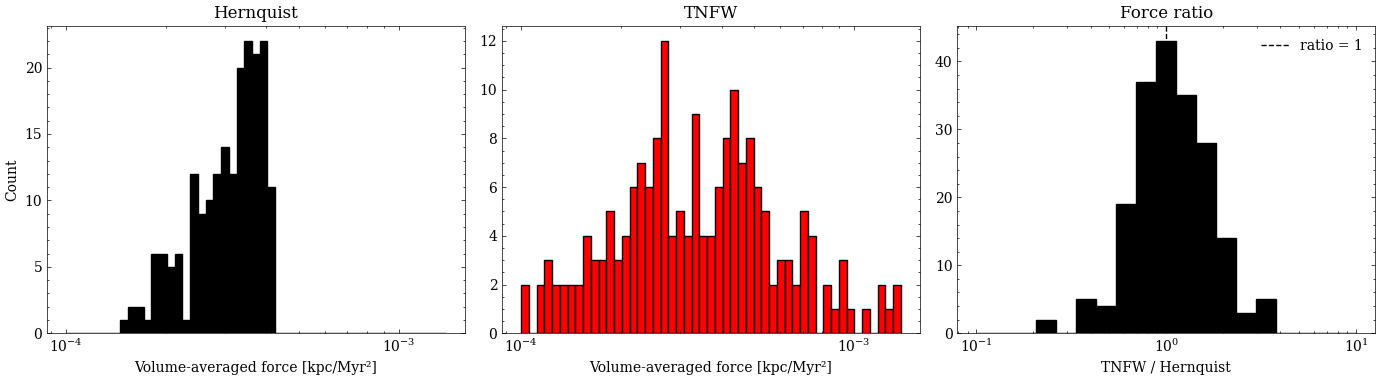

In [35]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

all_forces = jnp.concatenate([avg_forces_hernquist, avg_forces_tnfw])
all_forces = jnp.where(all_forces == 0, 1e-10, all_forces)
bins = jnp.logspace(-4, jnp.log10(all_forces.max()), 50)

axes[0].hist(avg_forces_hernquist, bins=bins, color='k', edgecolor='k')
axes[0].set_xscale('log')
axes[0].set_xlabel('Volume-averaged force [kpc/Myr²]')
axes[0].set_ylabel('Count')
axes[0].set_title('Hernquist')

axes[1].hist(avg_forces_tnfw, bins=bins, color='r', edgecolor='k')
axes[1].set_xscale('log')
axes[1].set_xlabel('Volume-averaged force [kpc/Myr²]')
axes[1].set_title('TNFW')

ratio = avg_forces_tnfw / avg_forces_hernquist
ratio = jnp.where(ratio == 0, 1e-10, ratio)
ratio_bins = jnp.logspace(-1, 1, 20)
axes[2].hist(ratio, bins=ratio_bins, color='k', edgecolor='k')
axes[2].set_xscale('log')
axes[2].set_xlabel('TNFW / Hernquist')
axes[2].set_title('Force ratio')
axes[2].axvline(1.0, color='k', linestyle='--', label='ratio = 1')
axes[2].legend()

plt.tight_layout()
plt.show()

Text(0, 0.5, 'density TNFW / density Hernquist (at fixed m_total)')

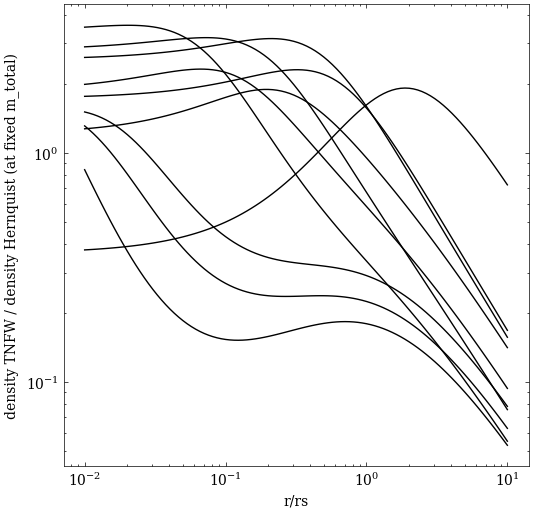

In [36]:
def rho_tnfw(r, rhos, rs, ft, rt):
    x = r / rs
    return rhos / (x * (1 + x)**2) / (1 + r**2 / rt**2)

def rho_hernquist(r, m_total, a):
    rho = m_total / (2 * jnp.pi * a**3)
    x = r / a
    return rho / x / (1 + x)**3

def tnfw_mean_density_mass_inside_rs(rhos, rs, ft, rt):
    tau = rt / rs
    prefactor = 3 * rhos * tau**2 / (1 + tau**2)
    term = jnp.log(2) + 0.5 - 0.5 * jnp.log(1 + tau**2) + jnp.arctan(1 / tau) / tau
    mean_density_inside_rs = ft * prefactor * term
    _r = jnp.logspace(-3, 0.0, 100)
    mass_inside_rs = []
    for i in range(0, len(rhos)):
        r = _r * rs[i]
        m = jnp.trapezoid(4 * jnp.pi * rho_tnfw(r, rhos[i], rs[i], ft[i], rt[i]) * r**2, r)
        mass_inside_rs.append(m)
    return mean_density_inside_rs, jnp.array(mass_inside_rs)

def hernquist_mean_density_mass_inside_a(m_total, a, r_match):
    """compute mean density and mass inside r_match"""
    rho = m_total / (2 * jnp.pi * a**3)
    x = r_match / a
    rho_mean = 1.5 * rho / x / (1 + x)**2
    m_enclosed = m_total * x**2 / (1 + x)**2
    return rho_mean, m_enclosed

# eqx_everything: _tidally_evolved_nfw_params instead of tidally_evolved_nfw_params_from_infall
rhos, rs, ft, rt = tidally_evolved_nfw_params_from_infall(m_infall, c_infall, z_infall, f_bound)

rho_mean_tnfw, m_tnfw = tnfw_mean_density_mass_inside_rs(rhos, rs, ft, rt)
r_match = rs
rho_mean_hernquist, m_hern = hernquist_mean_density_mass_inside_a(m_hernquist, rs_hernquist, r_match=r_match)

fig = plt.figure()
fig.set_size_inches(6, 6)
ax = plt.subplot(111)
_r = jnp.logspace(-2., 1, 100)
for i in range(0, 10):
    plt.loglog(_r, rho_tnfw(_r * rs[i], rhos[i], rs[i], ft[i], rt[i]) / rho_hernquist(_r * rs[i], m_hernquist[i], rs_hernquist[i]), color='k')
ax.set_xlabel('r/rs')
ax.set_ylabel('density TNFW / density Hernquist (at fixed m_total)')

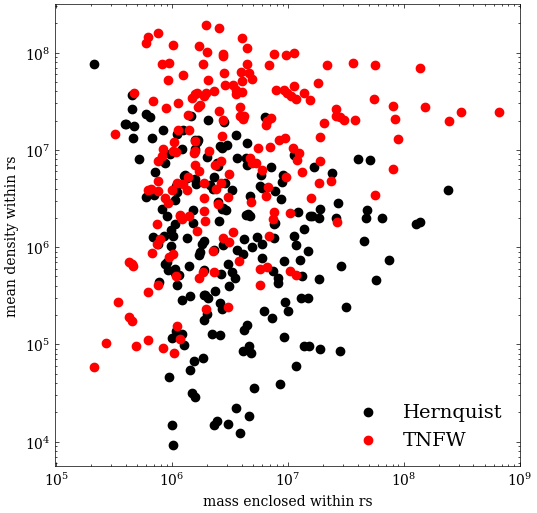

In [37]:
fig = plt.figure()
fig.set_size_inches(6, 6)
ax = plt.subplot(111)

ax.scatter(m_hern, rho_mean_hernquist, color='k', label='Hernquist')
ax.scatter(m_tnfw, rho_mean_tnfw, color='r', label='TNFW')
ax.legend(fontsize=14)
ax.set_xlabel('mass enclosed within rs')
ax.set_ylabel('mean density within rs')
ax.set_xscale('log')
ax.set_yscale('log')